# COEF — Feature Selection for `milk_kg` / `protein_p`  (corrected)

Selects predictors for milk yield and protein % and checks their multicollinearity. This version fixes
four correctness issues found in review:

1. **Lags recomputed *within lactation*** (`Animal × parity`) — the stored lags were self-filled at
   each series start (~17% leakage); lagging without parity crosses dry periods.
2. **Heat measured as the THI *anomaly*** (THI − farm-month normal), not raw same-day THI — raw THI is
   season-confounded (milk & THI both peak in summer, giving the wrong `+` sign).
3. **VIF computed with a constant** (statsmodels needs an intercept, else the magnitudes are wrong).
4. **One THI index only + within-animal effects** — `THI_1≈THI_2` (r=1.0) and `*_Compose≈*_avg`
   (r=0.99), so the old multi-THI mixed model produced collinearity-artifact coefficients. Replaced with
   the within-animal fixed-effects estimate used in `Climate_Signal_Analysis.ipynb`.
5. **No rows dropped.** Lags are undefined only at the first 1–2 test-days of each (short, ~7-point)
   lactation. Rather than drop those rows globally, each step handles its own missing values (pairwise),
   so every sample is used where it can be. The lag `NaN` are left as-is — **not** back-filled, since
   filling the first-test lag with the current value re-introduces the leakage this notebook fixed.

In [ ]:
path = '../../Thesis_Data/'
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(path + 'Final_Data/Final_Merged_Data.csv')
df['dtt']   = pd.to_datetime(df['dtt'], errors='coerce')            # parse dates (were sorted as strings)
df['AFC']   = pd.to_timedelta(df['AFC'], errors='coerce').dt.days   # '1088 days' -> 1088
df['month'] = df['dtt'].dt.month
df['farm']  = df['Farm_Code'].astype(str)
df = df.sort_values(['Farm_Code', 'Animal_ID', 'parity', 'dtt']).reset_index(drop=True)
print(f'{len(df):,} records | {df.Animal_ID.nunique():,} animals | {df.Farm_Code.nunique()} farms')

1,631,410 records | 90,532 animals | 316 farms


In [ ]:
# FIX 1 — recompute lags WITHIN lactation (Animal x parity).
lac = df.groupby(['Farm_Code', 'Animal_ID', 'parity'])
for c in ['milk_kg', 'protein_p']:
    df[f'{c}_lag1'] = lac[c].shift(1)
    df[f'{c}_lag2'] = lac[c].shift(2)

# FIX 2 — deseasonalize heat: anomaly = index above each farm's calendar-month normal.
for idx in ['THI_1_avg', 'WHI_avg']:
    df[f'{idx}_anom'] = df[idx] - df.groupby(['farm', 'month'])[idx].transform('mean')
# heat exposure just before the test-day (previous test-day anomaly, within lactation)
df['THI_1_avg_anom_lag1'] = df.groupby(['Farm_Code', 'Animal_ID', 'parity'])['THI_1_avg_anom'].shift(1)

# Show the effect of fixing the lags (within-lactation vs the two wrong versions)
print('milk_kg_lag1 vs milk_kg  (Pearson r):')
print(f"  stored (leaky, self-filled)       : {pd.read_csv(path+'Final_Data/Final_Merged_Data.csv', usecols=['milk_kg','milk_kg_lag1']).dropna().corr().iloc[0,1]:.4f}")
print(f"  within-lactation (this notebook)  : {df[['milk_kg','milk_kg_lag1']].dropna().corr().iloc[0,1]:.4f}")

milk_kg_lag1 vs milk_kg  (Pearson r):
  stored (leaky, self-filled)       : 0.7458
  within-lactation (this notebook)  : 0.6920


In [ ]:
# FIX 4 — keep ONE THI family (THI_2 == THI_1 r=1.0; *_Compose ~ *_avg r=0.99).
targets  = ['milk_kg', 'protein_p']
animal   = ['DIM', 'AFC', 'parity']
climate  = ['temperature_avg', 'humidity_avg', 'wind_speed_avg',
            'THI_1_avg', 'THI_1_avg_anom', 'THI_1_avg_anom_lag1', 'WHI_avg_anom']
lags     = ['milk_kg_lag1', 'milk_kg_lag2', 'protein_p_lag1', 'protein_p_lag2']
features = animal + climate + lags

# FIX 5 — keep ALL rows; no global dropna. Each analysis below handles its own NaN (pairwise),
# so the first tests of each lactation stay in the climate/correlation work instead of being dropped.
analysis_df = df                       # full data, nothing dropped
print(f'analysis rows: {len(analysis_df):,} (all kept)  |  {len(features)} candidate features')
print('missing only at lactation starts (lag features):')
print(analysis_df[lags].isna().sum().to_string())

analysis rows: 1,631,410 (all kept)  |  14 candidate features
missing only at lactation starts (lag features):
milk_kg_lag1      244915
milk_kg_lag2      489830
protein_p_lag1    244915
protein_p_lag2    489830


In [ ]:
from scipy import stats
rows = []
for tgt in targets:
    for feat in features:
        d = analysis_df[[feat, tgt]].dropna()          # pairwise: each feature uses its own available rows
        rows.append({'target': tgt, 'feature': feat, 'n': len(d),
                     'pearson_r':  round(stats.pearsonr(d[feat], d[tgt])[0], 4),
                     'spearman_r': round(stats.spearmanr(d[feat], d[tgt])[0], 4)})
corr_df = pd.DataFrame(rows)
corr_df.to_csv('correlation_results.csv', index=False)

# NOTE: at n>1M every p-value ~ 0, so significance is automatic -> rank by |r| (effect size).
# 'n' shows rows used: non-lag features ~1.63M, lag features ~1.39M (first tests have no lag).
mk = corr_df[corr_df.target == 'milk_kg'].copy()
mk = mk.reindex(mk.pearson_r.abs().sort_values(ascending=False).index)
print('milk_kg correlations (|Pearson| desc; n = rows used per feature):')
print(mk.to_string(index=False))

print('\nSeason-confound check — raw same-day THI vs its deseasonalized anomaly:')
for f in ['THI_1_avg', 'THI_1_avg_anom']:
    d = analysis_df[[f, 'milk_kg']].dropna()
    print(f"  corr({f:20s}, milk_kg) = {d[f].corr(d['milk_kg']):+.4f}")

milk_kg correlations (|Pearson| desc; n = rows used per feature):
 target             feature       n  pearson_r  spearman_r
milk_kg        milk_kg_lag1 1386495     0.6920      0.6950
milk_kg        milk_kg_lag2 1141580     0.6363      0.6414
milk_kg                 DIM 1631410    -0.5492     -0.5621
milk_kg      protein_p_lag1 1386495    -0.2606     -0.2844
milk_kg      protein_p_lag2 1141580    -0.1977     -0.2215
milk_kg              parity 1631410     0.0768      0.1110
milk_kg                 AFC 1630484     0.0713      0.1037
milk_kg           THI_1_avg 1631410     0.0610      0.0647
milk_kg     temperature_avg 1631410     0.0608      0.0647
milk_kg        humidity_avg 1631410    -0.0513     -0.0487
milk_kg      wind_speed_avg 1631410    -0.0091      0.0011
milk_kg THI_1_avg_anom_lag1 1386495     0.0047      0.0050
milk_kg      THI_1_avg_anom 1631410     0.0013      0.0017
milk_kg        WHI_avg_anom 1631410    -0.0009     -0.0037

Season-confound check — raw same-day THI vs its 

saved correlation_heatmap.png


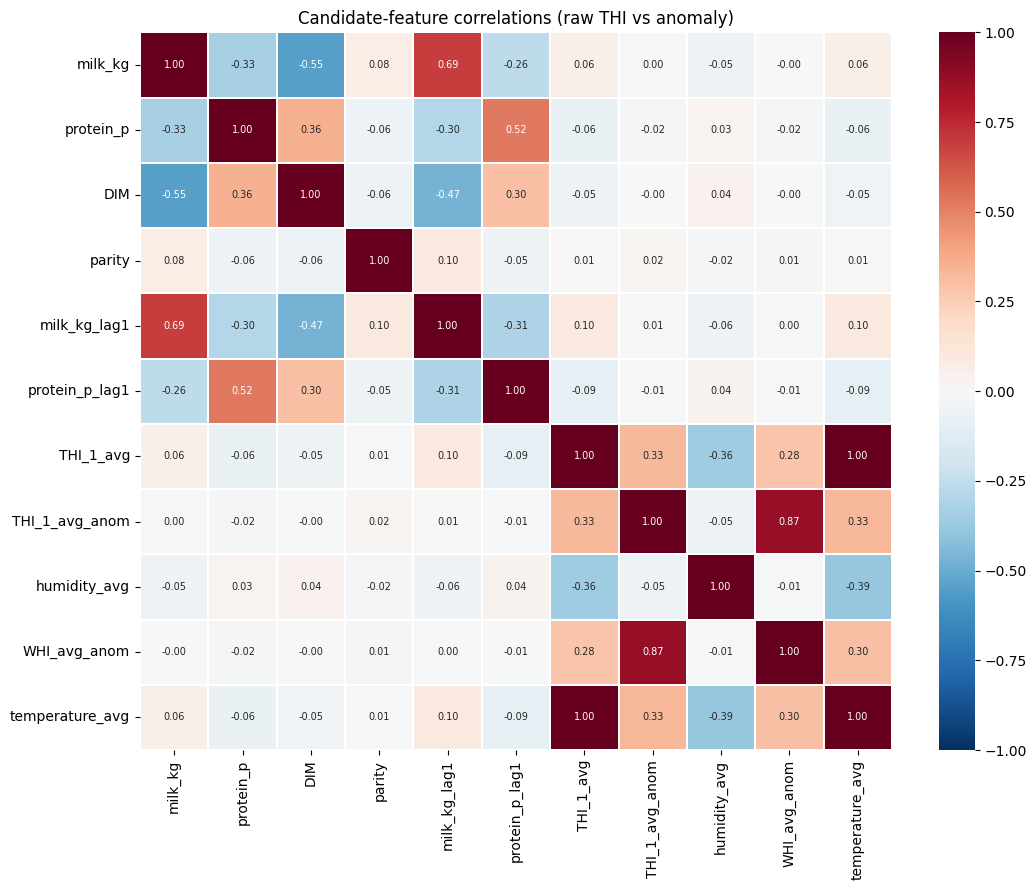

In [ ]:
# Correlation heatmap: raw THI (confounded) sits next to its anomaly for contrast.
import seaborn as sns
hm = ['milk_kg', 'protein_p', 'DIM', 'parity', 'milk_kg_lag1', 'protein_p_lag1',
      'THI_1_avg', 'THI_1_avg_anom', 'humidity_avg', 'WHI_avg_anom', 'temperature_avg']
plt.figure(figsize=(11, 9))
sns.heatmap(analysis_df[hm].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.3)
plt.title('Candidate-feature correlations (raw THI vs anomaly)')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
print('saved correlation_heatmap.png')

In [ ]:
# FIX 3 — VIF WITH a constant (statsmodels needs an intercept).
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(frame, feats):
    X = sm.add_constant(frame[feats].dropna())
    return (pd.DataFrame({'feature': feats,
              'VIF': [round(variance_inflation_factor(X.values, X.columns.get_loc(f)), 2) for f in feats]})
            .sort_values('VIF', ascending=False).reset_index(drop=True))

cand = ['DIM', 'AFC', 'parity', 'THI_1_avg_anom', 'humidity_avg', 'WHI_avg_anom',
        'milk_kg_lag1', 'protein_p_lag1']
print('VIF (with constant) on the candidate set — all low = no multicollinearity:')
print(vif_table(analysis_df, cand).to_string(index=False))

VIF (with constant) on the candidate set — all low = no multicollinearity:
       feature   VIF
        parity 12.00
           AFC 11.98
THI_1_avg_anom  4.11
  WHI_avg_anom  4.10
  milk_kg_lag1  1.35
           DIM  1.33
protein_p_lag1  1.15
  humidity_avg  1.01


In [ ]:
# FIX 4 — clean weather effect: within-animal fixed effects + farm-clustered SE, DIM controlled,
# ONE deseasonalized heat term. (Same method as Climate_Signal_Analysis.ipynb.)
import statsmodels.formula.api as smf

def within_animal_fe(frame, y, xs, cluster='Farm_Code'):
    f = frame.dropna(subset=[y] + xs + [cluster, 'Animal_ID']).copy()
    for c in [y] + xs:
        f[c] = f[c] - f.groupby('Animal_ID')[c].transform('mean')   # animal demeaning = animal FE
    return smf.ols(f"{y} ~ " + " + ".join(xs) + " - 1", f).fit(
        cov_type='cluster', cov_kwds={'groups': f[cluster]})

for tgt in targets:
    res = within_animal_fe(analysis_df, tgt, ['DIM', 'THI_1_avg_anom', 'humidity_avg'])
    print(f'=== {tgt}: within-animal effect (DIM-controlled, farm-clustered SE) ===')
    print(res.summary().tables[1]); print()

=== milk_kg: within-animal effect (DIM-controlled, farm-clustered SE) ===
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
DIM               -0.0251      0.000    -69.174      0.000      -0.026      -0.024
THI_1_avg_anom    -0.0037      0.002     -1.770      0.077      -0.008       0.000
humidity_avg      -0.0023      0.001     -2.918      0.004      -0.004      -0.001

=== protein_p: within-animal effect (DIM-controlled, farm-clustered SE) ===
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
DIM                0.0019   5.03e-05     37.391      0.000       0.002       0.002
THI_1_avg_anom    -0.0024      0.000     -6.404      0.000      -0.003      -0.002
humidity_avg       0.0005      0.000      3.710      0.000       0.000       0.001



In [ ]:
import json
# Autoregressive lag-1 + DIM dominate; the real (deseasonalized) climate signal is small.
# Climate features are ANOMALIES, not raw THI.
selected_features = {
    # VIF-clean, for statistical interpretation
    'milk_kg_stats':     ['DIM', 'milk_kg_lag1'],
    'protein_p_stats':   ['DIM', 'protein_p_lag1'],
    # climate-focused (deseasonalized)
    'milk_kg_climate':   ['DIM', 'THI_1_avg_anom', 'THI_1_avg_anom_lag1'],
    'protein_p_climate': ['DIM', 'WHI_avg_anom', 'THI_1_avg_anom_lag1'],
    # fuller sets for ML / forecasting (collinearity OK for pure prediction)
    'milk_kg_ml':        ['DIM', 'parity', 'milk_kg_lag1', 'milk_kg_lag2', 'THI_1_avg_anom', 'THI_1_avg_anom_lag1'],
    'protein_p_ml':      ['DIM', 'parity', 'protein_p_lag1', 'protein_p_lag2', 'WHI_avg_anom', 'THI_1_avg_anom_lag1'],
}
with open('selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)
print(json.dumps(selected_features, indent=2))

{
  "milk_kg_stats": [
    "DIM",
    "milk_kg_lag1"
  ],
  "protein_p_stats": [
    "DIM",
    "protein_p_lag1"
  ],
  "milk_kg_climate": [
    "DIM",
    "THI_1_avg_anom",
    "THI_1_avg_anom_lag1"
  ],
  "protein_p_climate": [
    "DIM",
    "WHI_avg_anom",
    "THI_1_avg_anom_lag1"
  ],
  "milk_kg_ml": [
    "DIM",
    "parity",
    "milk_kg_lag1",
    "milk_kg_lag2",
    "THI_1_avg_anom",
    "THI_1_avg_anom_lag1"
  ],
  "protein_p_ml": [
    "DIM",
    "parity",
    "protein_p_lag1",
    "protein_p_lag2",
    "WHI_avg_anom",
    "THI_1_avg_anom_lag1"
  ]
}
